# Chapter 15: A First Look at Predictive Modeling

*Data Analytics with Python and Jupyter Notebook*

Run each cell in order with **Shift + Enter**. In this notebook we:

1. Predict daily store revenue from the weather, the day and promotions (regression)
2. Evaluate the model against a baseline on held-out test data
3. See overfitting and data leakage happen
4. Predict which loyalty members will churn (classification)

## 15.1 Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 80)

## 15.2 The revenue data

In [2]:
daily = pd.read_csv("../data/ch15_daily_weather_revenue.csv",
                    parse_dates=["date"])
daily.head()

,date,store,day_of_week,temp_c,rain_mm,promo,transactions,revenue
0,2025-01-01,Downtown,Wednesday,0.0,0.0,0,101,734.77
1,2025-01-01,University,Wednesday,0.0,0.0,0,50,369.49
2,2025-01-01,Riverside,Wednesday,0.0,0.0,0,57,446.96
3,2025-01-02,Downtown,Thursday,2.4,0.0,0,98,735.90
4,2025-01-02,University,Thursday,2.4,0.0,0,50,370.78


In [3]:
daily.shape

(1092, 8)

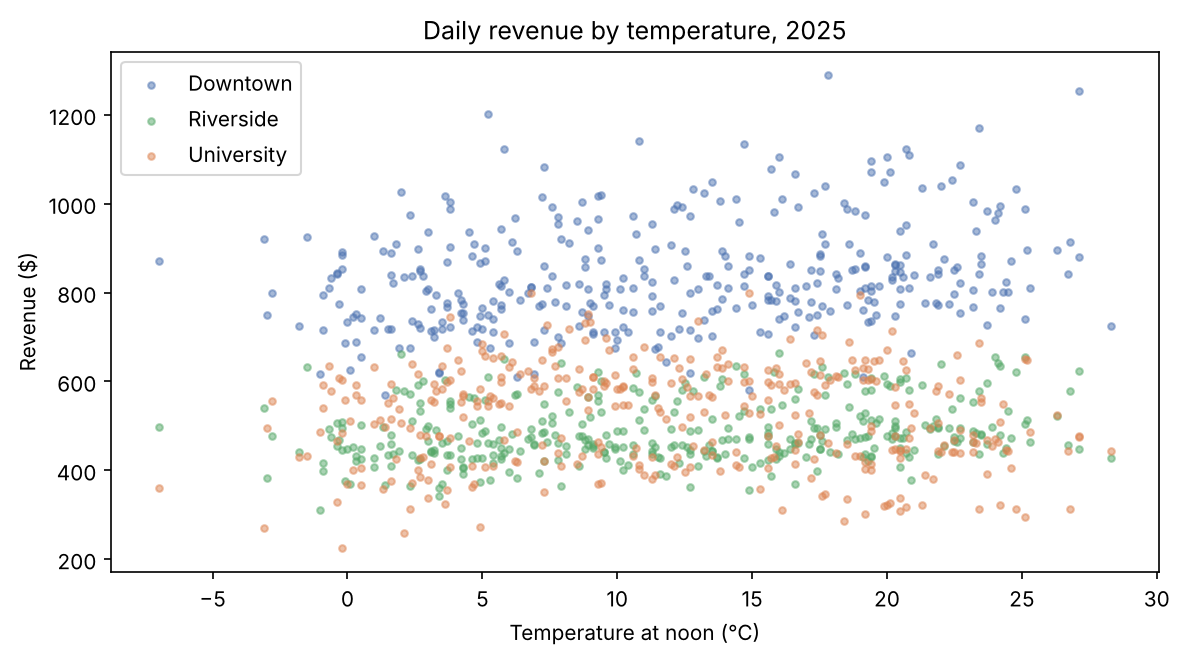

In [4]:
colors = {"Downtown": "#4C72B0", "University": "#DD8452",
          "Riverside": "#55A868"}

fig, ax = plt.subplots(figsize=(8, 4.5))
for store, rows in daily.groupby("store"):
    ax.scatter(rows["temp_c"], rows["revenue"], s=10, alpha=0.5,
               color=colors[store], label=store)
ax.set_title("Daily revenue by temperature, 2025")
ax.set_xlabel("Temperature at noon (°C)")
ax.set_ylabel("Revenue ($)")
ax.legend()
plt.tight_layout()
plt.show()

## 15.3 Features and target

In [5]:
daily["weekend"] = (daily["date"].dt.dayofweek >= 5).astype(int)

features = ["store", "temp_c", "rain_mm", "promo", "weekend"]
X = pd.get_dummies(daily[features], columns=["store"],
                   drop_first=True, dtype=int)
y = daily["revenue"]
X.head()

,temp_c,rain_mm,promo,weekend,store_Riverside,store_University
0,0.0,0.0,0,0,0,0
1,0.0,0.0,0,0,0,1
2,0.0,0.0,0,0,1,0
3,2.4,0.0,0,0,0,0
4,2.4,0.0,0,0,0,1


## 15.4 Train/test split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)
print(X_train.shape, X_test.shape)

(819, 6) (273, 6)


## 15.5 A first regression model

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 2.05, -5.23, 49.29, 52.39,-353.54,-318.44]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['temp_c','rain_mm','promo','weekend','store_Riverside','store_University']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,804.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [8]:
coefs = pd.Series(model.coef_, index=X.columns).round(2)
print(f"Intercept: {model.intercept_:.2f}")
coefs

Intercept: 804.88


temp_c                2.05
rain_mm              -5.23
promo                49.29
weekend              52.39
store_Riverside    -353.54
store_University   -318.44
dtype: float64

## 15.6 Evaluating the model

In [9]:
from sklearn.metrics import (mean_absolute_error,
                             root_mean_squared_error, r2_score)

pred = model.predict(X_test)
baseline = np.full(len(y_test), y_train.mean())

for name, guess in [("Baseline", baseline), ("Linear model", pred)]:
    mae = mean_absolute_error(y_test, guess)
    rmse = root_mean_squared_error(y_test, guess)
    r2 = r2_score(y_test, guess)
    print(f"{name:<13} MAE {mae:6.1f}  RMSE {rmse:6.1f}  R² {r2:5.2f}")

Baseline      MAE  153.9  RMSE  185.9  R² -0.00
Linear model  MAE   78.8  RMSE  101.4  R²  0.70


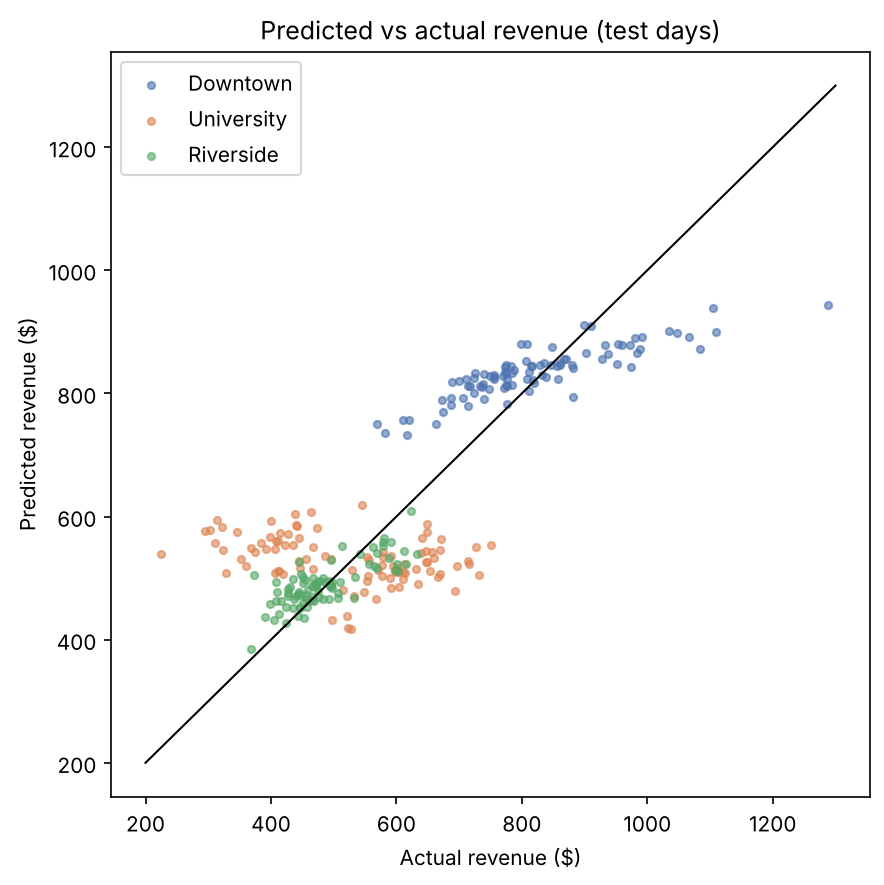

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
test_stores = daily.loc[y_test.index, "store"]
for store, color in colors.items():
    mask = test_stores == store
    ax.scatter(y_test[mask], pred[mask], s=12, alpha=0.6,
               color=color, label=store)
ax.plot([200, 1300], [200, 1300], color="black", linewidth=1)
ax.set_title("Predicted vs actual revenue (test days)")
ax.set_xlabel("Actual revenue ($)")
ax.set_ylabel("Predicted revenue ($)")
ax.legend()
plt.tight_layout()
plt.show()

### Where is the model wrong?

In [11]:
test = daily.loc[y_test.index].assign(error=y_test - pred)
test.pivot_table(index="store", columns="weekend", values="error",
                 aggfunc="mean").round(0)

weekend,0,1
store,,
Downtown,-55.0,97.0
Riverside,-18.0,45.0
University,83.0,-170.0


In [12]:
uni = test[test["store"] == "University"]
uni.groupby(uni["date"].dt.month)["error"].mean().round(0)

date
1     -44.0
2     -21.0
3     -52.0
4      21.0
5     -12.0
6     -23.0
7    -140.0
8    -146.0
9     108.0
10     93.0
11     13.0
12     87.0
Name: error, dtype: float64

### Better features

In [13]:
def add_features(df):
    out = df.copy()
    uni = out["store"] == "University"
    month, day = out["date"].dt.month, out["date"].dt.day
    students_away = (month.isin([7, 8]) | ((month == 12) & (day >= 20))
                     | ((month == 1) & (day <= 8)))
    out["uni_weekend"] = (uni & (out["weekend"] == 1)).astype(int)
    out["uni_break"] = (uni & students_away).astype(int)
    return out

daily = add_features(daily)
features2 = features + ["uni_weekend", "uni_break"]
X2 = pd.get_dummies(daily[features2], columns=["store"],
                    drop_first=True, dtype=int)
X2_train, X2_test = X2.loc[X_train.index], X2.loc[X_test.index]

model2 = LinearRegression().fit(X2_train, y_train)
pred2 = model2.predict(X2_test)
print(f"MAE {mean_absolute_error(y_test, pred2):.1f}  "
      f"R² {r2_score(y_test, pred2):.2f}")

MAE 38.9  R² 0.93


In [14]:
pd.Series(model2.coef_, index=X2.columns).round(1)

temp_c                3.0
rain_mm              -5.7
promo                53.9
weekend             147.8
uni_weekend        -314.8
uni_break          -162.2
store_Riverside    -355.1
store_University   -194.6
dtype: float64

### Using the model

In [15]:
new_days = pd.DataFrame({
    "temp_c": [24.0, 24.0, 3.0],
    "rain_mm": [0.0, 0.0, 12.0],
    "promo": [1, 1, 0],
    "weekend": [1, 1, 0],
    "uni_weekend": [0, 1, 0],
    "uni_break": [0, 0, 0],
    "store_Riverside": [0, 0, 1],
    "store_University": [0, 1, 0],
}, index=["Downtown, sunny Sat, promo",
          "University, sunny Sat, promo",
          "Riverside, wet weekday"])
model2.predict(new_days[X2.columns]).round(0)

array([1040.,  530.,  352.])

## 15.7 Overfitting

In [16]:
from sklearn.tree import DecisionTreeRegressor

rows = []
for depth in [1, 2, 3, 4, 5, 6, 8, 10, 15, 20]:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X2_train, y_train)
    rows.append({
        "depth": depth,
        "train_mae": mean_absolute_error(y_train,
                                         tree.predict(X2_train)),
        "test_mae": mean_absolute_error(y_test, tree.predict(X2_test)),
    })
depths = pd.DataFrame(rows).set_index("depth").round(1)
depths

,train_mae,test_mae
depth,,
1,128.1,124.4
2,71.9,81.0
3,53.0,52.7
4,40.9,43.3
5,36.2,40.7
6,32.4,40.4
8,25.2,38.1
10,18.2,40.4
15,6.2,43.3


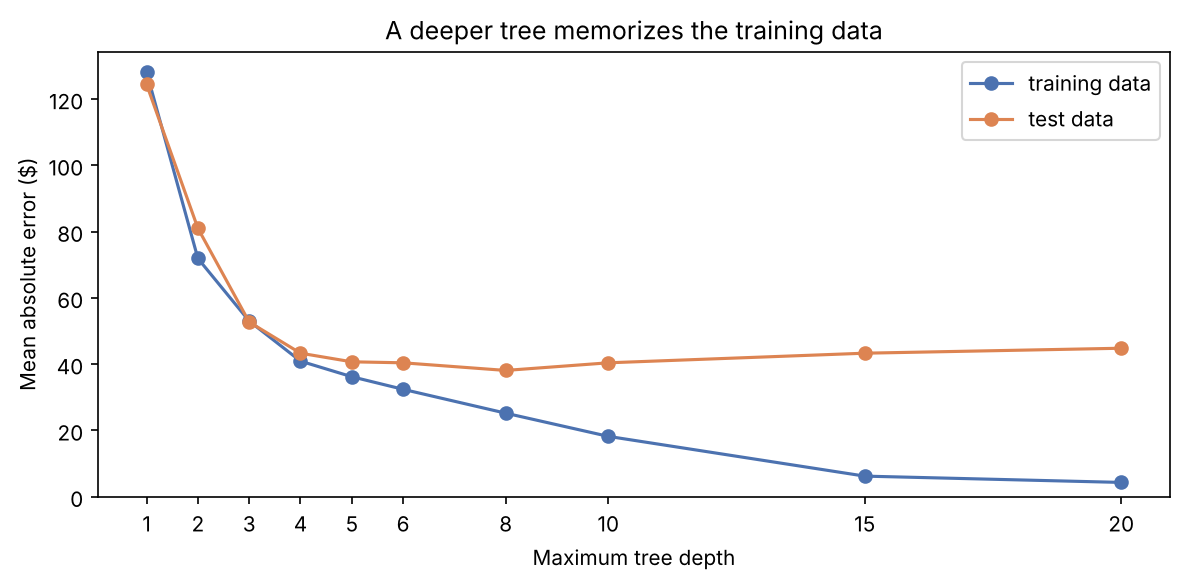

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(depths.index, depths["train_mae"], marker="o", color="#4C72B0",
        label="training data")
ax.plot(depths.index, depths["test_mae"], marker="o", color="#DD8452",
        label="test data")
ax.set_title("A deeper tree memorizes the training data")
ax.set_xlabel("Maximum tree depth")
ax.set_xticks(depths.index)
ax.set_ylabel("Mean absolute error ($)")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

### Cross-validation

In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LinearRegression(), X2, y, cv=5,
                         scoring="neg_mean_absolute_error")
print((-scores).round(1))
print(f"Average MAE: {-scores.mean():.1f}")

[45.4 37.1 35.7 36.2 56.8]
Average MAE: 42.2


## 15.8 Data leakage

In [19]:
X_leak = X2.assign(transactions=daily["transactions"])
leaky = LinearRegression().fit(X_leak.loc[X_train.index], y_train)
leak_pred = leaky.predict(X_leak.loc[X_test.index])
print(f"MAE {mean_absolute_error(y_test, leak_pred):.1f}  "
      f"R² {r2_score(y_test, leak_pred):.3f}")

MAE 15.6  R² 0.988


### Respect time: train on the past, test on the future

In [20]:
past = daily["date"] < "2025-10-01"
future = ~past

time_model = LinearRegression().fit(X2[past], y[past])
time_pred = time_model.predict(X2[future])
print(f"Train on Jan-Sep, test on Oct-Dec: "
      f"MAE {mean_absolute_error(y[future], time_pred):.1f}")

Train on Jan-Sep, test on Oct-Dec: MAE 53.0


## 15.9 Classification: which members will churn?

In [21]:
members = pd.read_csv("../data/ch15_loyalty_churn.csv")
members.head()

,member_id,home_store,tenure_months,visits_90d,days_since_last_visit,avg_ticket,mobile_app,offers_redeemed_90d,winback_email_sent,churned
0,50001,University,19,29,3,9.47,1,2,0,0
1,50002,Riverside,37,2,23,7.03,1,0,0,0
2,50003,Downtown,53,9,6,5.56,0,2,0,0
3,50004,University,38,12,3,8.18,0,3,0,0
4,50005,Riverside,28,3,48,8.81,1,1,0,0


In [22]:
members["churned"].value_counts(normalize=True)

churned
0    0.805333
1    0.194667
Name: proportion, dtype: float64

In [23]:
features = ["tenure_months", "visits_90d", "days_since_last_visit",
            "avg_ticket", "mobile_app", "offers_redeemed_90d"]
X = members[features]
y = members["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print(f"Churn rate, train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Churn rate, train: 0.195, test: 0.195


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

clf = make_pipeline(StandardScaler(), LogisticRegression())
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

### Accuracy and the baseline

In [25]:
from sklearn.metrics import accuracy_score

print(f"Model accuracy:    {accuracy_score(y_test, pred):.3f}")
print(f"'Nobody churns':   {1 - y_test.mean():.3f}")

Model accuracy:    0.859
'Nobody churns':   0.805


### The confusion matrix

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
pd.DataFrame(cm, index=["actual: stayed", "actual: churned"],
             columns=["predicted: stay", "predicted: churn"])

,predicted: stay,predicted: churn
actual: stayed,589,15
actual: churned,91,55


In [27]:
from sklearn.metrics import precision_score, recall_score

print(f"Precision: {precision_score(y_test, pred):.2f}")
print(f"Recall:    {recall_score(y_test, pred):.2f}")

Precision: 0.79
Recall:    0.38


### Probabilities and thresholds

In [28]:
proba = clf.predict_proba(X_test)[:, 1]
for threshold in [0.5, 0.3]:
    flagged = (proba >= threshold).astype(int)
    print(f"threshold {threshold}: flagged {flagged.sum():3d}, "
          f"precision {precision_score(y_test, flagged):.2f}, "
          f"recall {recall_score(y_test, flagged):.2f}")

threshold 0.5: flagged  70, precision 0.79, recall 0.38


threshold 0.3: flagged 175, precision 0.49, recall 0.59


### What drives churn?

In [29]:
weights = clf.named_steps["logisticregression"].coef_[0]
pd.Series(weights, index=features).sort_values().round(2)

visits_90d              -1.18
mobile_app              -0.44
offers_redeemed_90d     -0.34
tenure_months           -0.33
avg_ticket              -0.01
days_since_last_visit    0.69
dtype: float64

### A tree that memorizes

In [30]:
from sklearn.tree import DecisionTreeClassifier

for depth in [3, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    print(f"max_depth={depth}: "
          f"train {tree.score(X_train, y_train):.3f}, "
          f"test {tree.score(X_test, y_test):.3f}")

max_depth=3: train 0.850, test 0.840
max_depth=None: train 1.000, test 0.793


### Leakage in classification

In [31]:
leaky_features = features + ["winback_email_sent"]
Xl_train, Xl_test = (members.loc[X_train.index, leaky_features],
                     members.loc[X_test.index, leaky_features])
leaky_clf = make_pipeline(StandardScaler(), LogisticRegression())
leaky_clf.fit(Xl_train, y_train)
leaky_pred = leaky_clf.predict(Xl_test)
print(f"Accuracy {accuracy_score(y_test, leaky_pred):.3f}, "
      f"recall {recall_score(y_test, leaky_pred):.2f}")

Accuracy 0.937, recall 0.91


### Putting the model to work

In [32]:
at_risk = (members.loc[X_test.index, ["member_id", "home_store",
                                        "visits_90d",
                                        "days_since_last_visit"]]
           .assign(churn_risk=proba.round(2))
           .sort_values("churn_risk", ascending=False))
recent = at_risk["days_since_last_visit"] <= 30
at_risk[recent].head(8)

,member_id,home_store,visits_90d,days_since_last_visit,churn_risk
2889,52890,Downtown,1,24,0.73
588,50589,University,1,26,0.73
1286,51287,Downtown,1,29,0.71
2883,52884,University,2,19,0.66
1343,51344,University,4,26,0.66
2793,52794,Downtown,2,16,0.65
1931,51932,Downtown,1,22,0.65
2052,52053,Riverside,3,28,0.65


## Exercises

1. Fit a regression with **temperature as the only feature**. What are its test MAE and R²? What does that tell you about temperature on its own?
2. Replace the `weekend` column with one dummy column per day of the week (`pd.get_dummies` on `day_of_week`). Does the improved model get better?
3. Repeat the time-based split from Section 15.8 with the **original** five features from Section 15.3 (no University features). How much worse is it than the improved model's MAE of 53.0?
4. Try `RandomForestRegressor(n_estimators=200, random_state=42)` from `sklearn.ensemble` on the improved features. Compare its test MAE with the linear model's.
5. For the churn model, lower the threshold to 0.2. How many members are flagged, and what are precision and recall? When would that be a sensible choice?
6. Add `home_store` to the churn model (as dummy columns). Do accuracy and recall change? Which store's members are most likely to churn?
7. **Think about it:** use `pd.crosstab` to compare `winback_email_sent` with `churned`. Explain to a colleague why this column made the model look so good, and why it is useless for predicting churn on 31 December.